# Part 4 — XGBoost Model

## XGBoost Model

In [21]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred   = xgb_model.predict(X_val)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_val_rmse   = np.sqrt(mean_squared_error(y_val,   xgb_val_pred))
xgb_val_mae    = mean_absolute_error(y_val, xgb_val_pred)
xgb_val_r2     = r2_score(y_val, xgb_val_pred)

print(f"XGBoost â€” Train RMSE: ${xgb_train_rmse:,.2f}")
print(f"XGBoost â€” Val   RMSE: ${xgb_val_rmse:,.2f}")
print(f"XGBoost â€” Val   MAE : ${xgb_val_mae:,.2f}")
print(f"XGBoost â€” Val   RÂ²  : {xgb_val_r2:.4f}")

[0]	validation_0-rmse:21786.98966	validation_1-rmse:20962.58178
[50]	validation_0-rmse:3357.53299	validation_1-rmse:2803.58167
[100]	validation_0-rmse:2538.39828	validation_1-rmse:2264.21956
[150]	validation_0-rmse:2340.48821	validation_1-rmse:2235.84621
[200]	validation_0-rmse:2190.05147	validation_1-rmse:2219.73042
[250]	validation_0-rmse:2093.35488	validation_1-rmse:2207.03423
[300]	validation_0-rmse:2008.26037	validation_1-rmse:2193.28875
[350]	validation_0-rmse:1932.84401	validation_1-rmse:2184.57953
[400]	validation_0-rmse:1867.53360	validation_1-rmse:2177.46063
[450]	validation_0-rmse:1815.01393	validation_1-rmse:2166.50930
[499]	validation_0-rmse:1773.73086	validation_1-rmse:2157.11483
XGBoost â€” Train RMSE: $1,773.73
XGBoost â€” Val   RMSE: $2,157.11
XGBoost â€” Val   MAE : $1,010.88
XGBoost â€” Val   RÂ²  : 0.9904


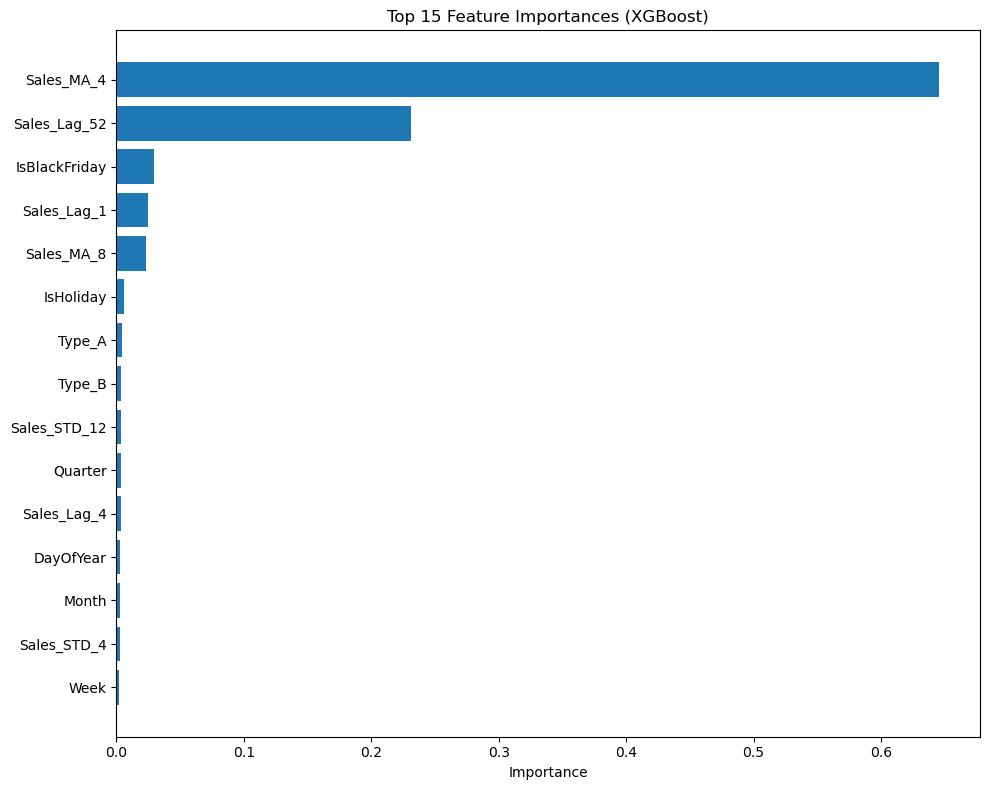

In [22]:
# Feature importance
feature_importance = pd.DataFrame({
    "feature":    available_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
top15 = feature_importance.head(15)
plt.barh(top15["feature"], top15["importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Residual Analysis (XGBoost)

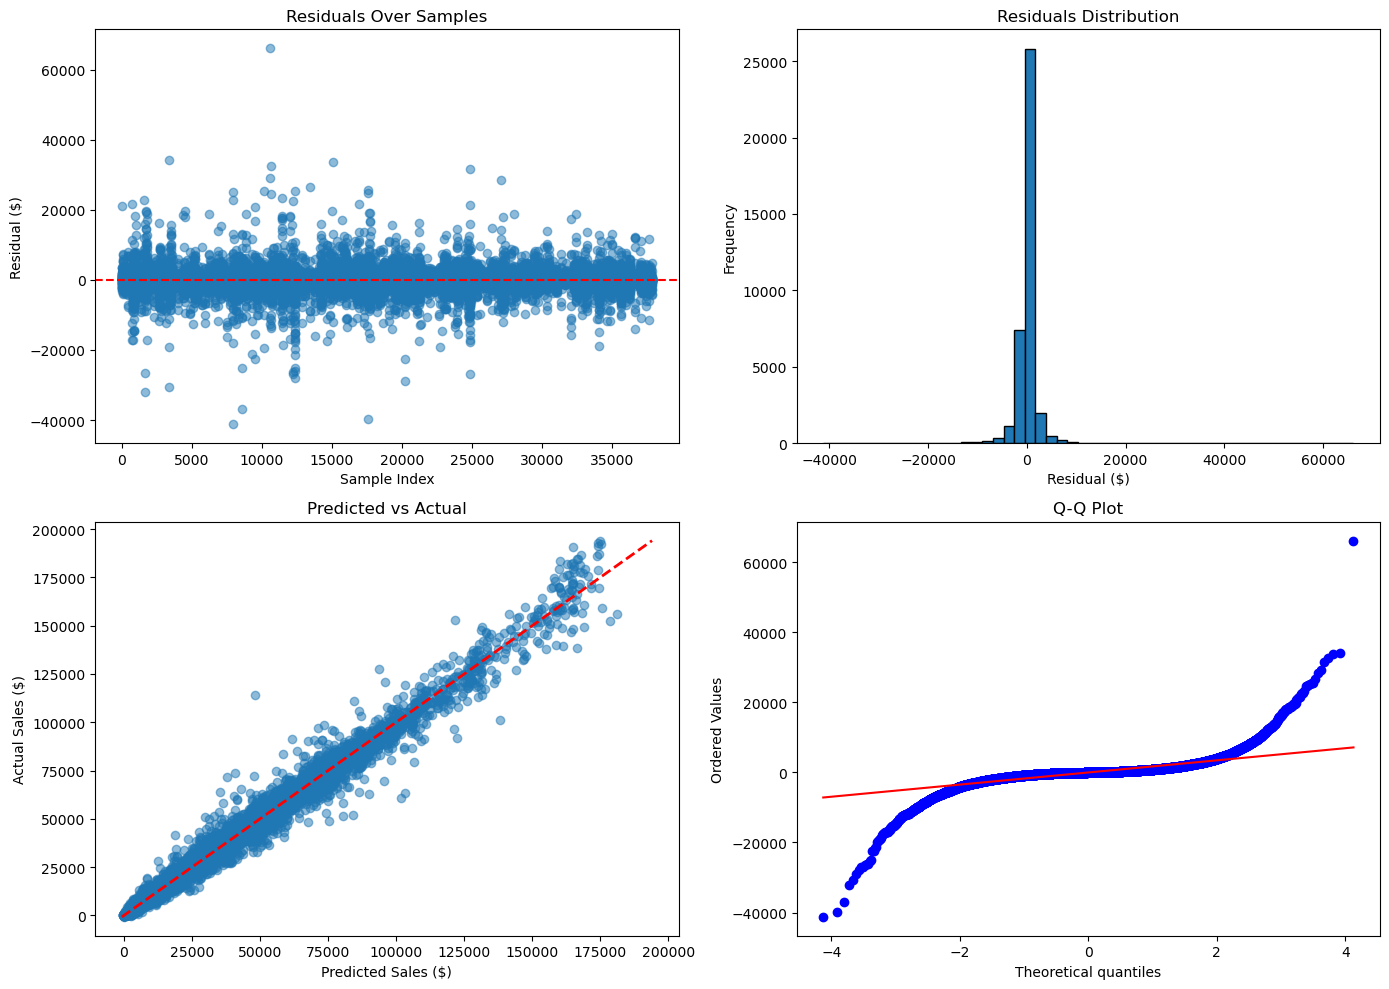

In [24]:
from scipy import stats

xgb_residuals = y_val.values - xgb_val_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(range(len(xgb_residuals)), xgb_residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals Over Samples")
axes[0, 0].set_xlabel("Sample Index")
axes[0, 0].set_ylabel("Residual ($)")

axes[0, 1].hist(xgb_residuals, bins=50, edgecolor="black")
axes[0, 1].set_title("Residuals Distribution")
axes[0, 1].set_xlabel("Residual ($)")
axes[0, 1].set_ylabel("Frequency")

axes[1, 0].scatter(xgb_val_pred, y_val.values, alpha=0.5)
axes[1, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--", lw=2)
axes[1, 0].set_title("Predicted vs Actual")
axes[1, 0].set_xlabel("Predicted Sales ($)")
axes[1, 0].set_ylabel("Actual Sales ($)")

stats.probplot(xgb_residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

## Model Comparison

  Model   Train_RMSE     Val_RMSE      Val_MAE   Val_R2
Prophet 1.756976e+06 1.413465e+06 1.207510e+06 0.078005
XGBoost 1.773731e+03 2.157115e+03 1.010877e+03 0.990421

Best model: XGBoost


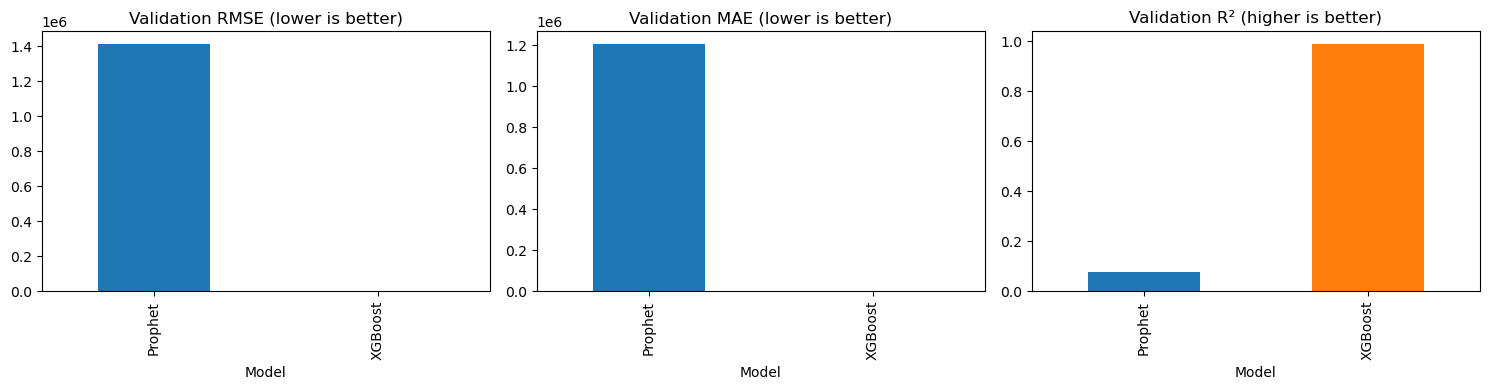

In [26]:
comparison = pd.DataFrame({
    "Model":      ["Prophet", "XGBoost"],
    "Train_RMSE": [prophet_train_rmse, xgb_train_rmse],
    "Val_RMSE":   [prophet_val_rmse,   xgb_val_rmse],
    "Val_MAE":    [prophet_val_mae,    xgb_val_mae],
    "Val_R2":     [prophet_val_r2,     xgb_val_r2],
})
print(comparison.to_string(index=False))

best_model = "Prophet" if prophet_val_rmse < xgb_val_rmse else "XGBoost"
print(f"\nBest model: {best_model}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparison.plot(x="Model", y="Val_RMSE", kind="bar", ax=axes[0], legend=False, color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("Validation RMSE (lower is better)")
comparison.plot(x="Model", y="Val_MAE",  kind="bar", ax=axes[1], legend=False, color=["#1f77b4", "#ff7f0e"])
axes[1].set_title("Validation MAE (lower is better)")
comparison.plot(x="Model", y="Val_R2",   kind="bar", ax=axes[2], legend=False, color=["#1f77b4", "#ff7f0e"])
axes[2].set_title("Validation RÂ² (higher is better)")
plt.tight_layout()
plt.show()

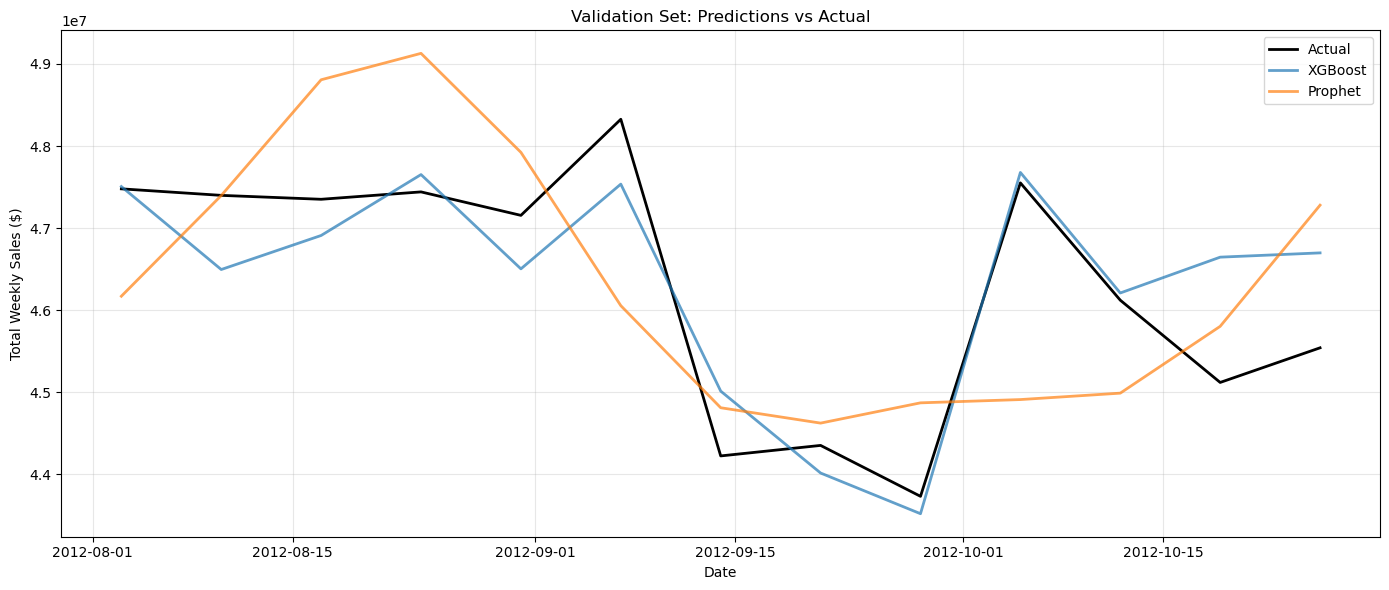

In [27]:
# Aggregate XGBoost predictions by date and overlay with Prophet
val_results = val[["Date", "Weekly_Sales"]].copy()
val_results["XGBoost_Pred"] = xgb_val_pred
val_agg = val_results.groupby("Date").agg({"Weekly_Sales": "sum", "XGBoost_Pred": "sum"}).reset_index()

prophet_val_df = prophet_val.copy()
prophet_val_df["Prophet_Pred"] = prophet_val_pred
val_agg = val_agg.merge(prophet_val_df[["ds", "Prophet_Pred"]], left_on="Date", right_on="ds", how="left")

plt.figure(figsize=(14, 6))
plt.plot(val_agg["Date"], val_agg["Weekly_Sales"],   label="Actual",  linewidth=2, color="black")
plt.plot(val_agg["Date"], val_agg["XGBoost_Pred"],  label="XGBoost", linewidth=2, alpha=0.7)
plt.plot(val_agg["Date"], val_agg["Prophet_Pred"],  label="Prophet", linewidth=2, alpha=0.7)
plt.title("Validation Set: Predictions vs Actual")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()